# Revenue Analysis

This notebook estimates annual revenue potential across NYC Airbnb listings by analyzing price, availability, and booking patterns. Revenue is estimated as: Price × (365 - Availability Days).

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv("../data/processed/processed_listings.csv")

In [51]:
# Calculate estimated annual revenue
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])
df["professional_host"] = df["calculated_host_listings_count"] > 1

In [52]:
# Neigbourhood Group with the highest total revenue
revenue_by_neigbourhood_group = df.groupby("neighbourhood_group")["estimated_annual_revenue"].sum().sort_values(ascending=False).reset_index()
revenue_by_neigbourhood_group

,neighbourhood_group,estimated_annual_revenue
0,Manhattan,980174785
1,Brooklyn,632908801
2,Queens,119324032
3,Bronx,17946934
4,Staten Island,6564156


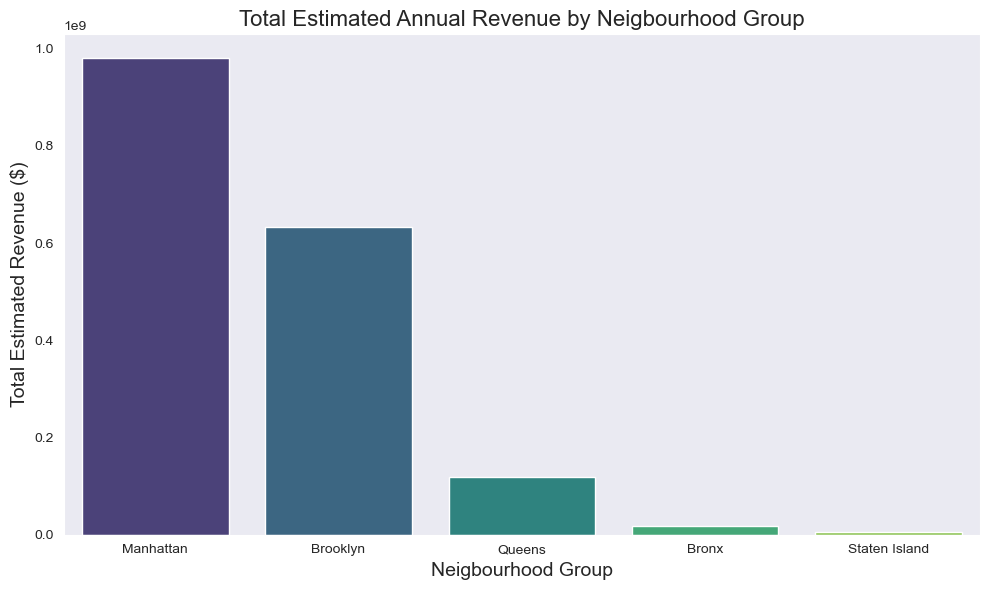

In [53]:
# Plotting total revenue by neigbourhood_group
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_neigbourhood_group, x="neighbourhood_group", y="estimated_annual_revenue", palette="viridis", hue="neighbourhood_group", legend=False)
plt.xlabel("Neigbourhood Group", fontsize=14)
plt.ylabel("Total Estimated Revenue ($)", fontsize=14)
plt.title("Total Estimated Annual Revenue by Neigbourhood Group", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/total_estimated_annual_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# Average revenue by listing by room type
room_type_avg_revenue =df.groupby("room_type")["estimated_annual_revenue"].mean().sort_values(ascending=False).reset_index()

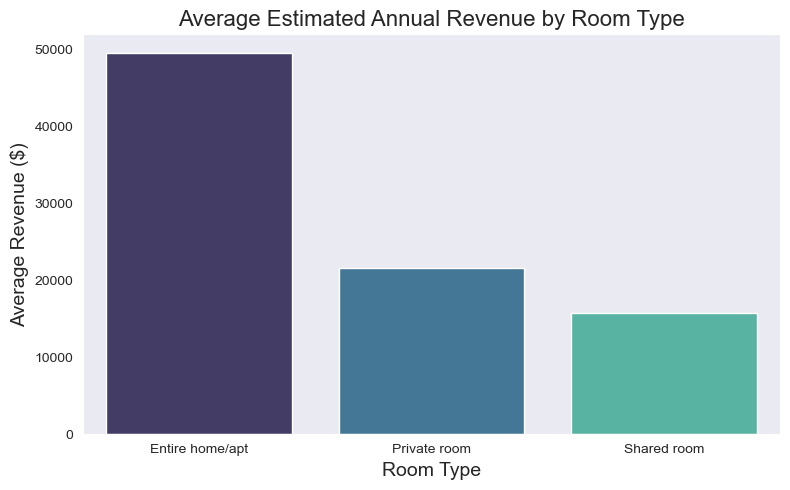

In [55]:
# Visualize average revenue by room type
plt.figure(figsize=(8, 5))
sns.barplot(data=room_type_avg_revenue, x="room_type", y="estimated_annual_revenue", estimator="mean", palette="mako", hue="room_type", legend=False)
plt.xlabel("Room Type", fontsize=14)
plt.ylabel("Average Revenue ($)", fontsize=14)
plt.title("Average Estimated Annual Revenue by Room Type", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/average_estimated_annual_revenue_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
# Average revenue by professional vs casual hosts
professional_host_avg_revenue = df.groupby("professional_host")["estimated_annual_revenue"].mean().reset_index()
professional_host_avg_revenue

,professional_host,estimated_annual_revenue
0,False,42332.075818
1,True,23490.944160


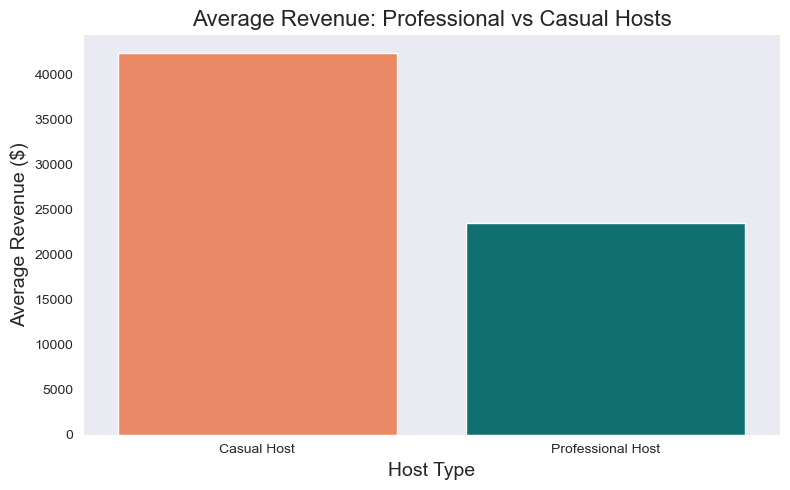

In [57]:
# Visualize revenue by host type
plt.figure(figsize=(8, 5))
sns.barplot(data=professional_host_avg_revenue, x="professional_host", y="estimated_annual_revenue", estimator="mean", palette=["coral", "teal"], hue="professional_host", legend=False)
plt.xlabel("Host Type", fontsize=14)
plt.ylabel("Average Revenue ($)", fontsize=14)
plt.title("Average Revenue: Professional vs Casual Hosts", fontsize=16)
plt.xticks([0, 1], ["Casual Host", "Professional Host"])
plt.tight_layout()
plt.savefig("../outputs/average_revenue_by_host_type.png", dpi=150, bbox_inches="tight")
plt.show()

        neighbourhood  estimated_annual_revenue
0        Williamsburg                 153054916
1     Upper West Side                 102616402
2        East Village                  94245896
3  Bedford-Stuyvesant                  93068424
4      Hell'S Kitchen                  85436299
5     Upper East Side                  80349413
6             Midtown                  80140635
7              Harlem                  76500583
8             Chelsea                  63447969
9            Bushwick                  53642318


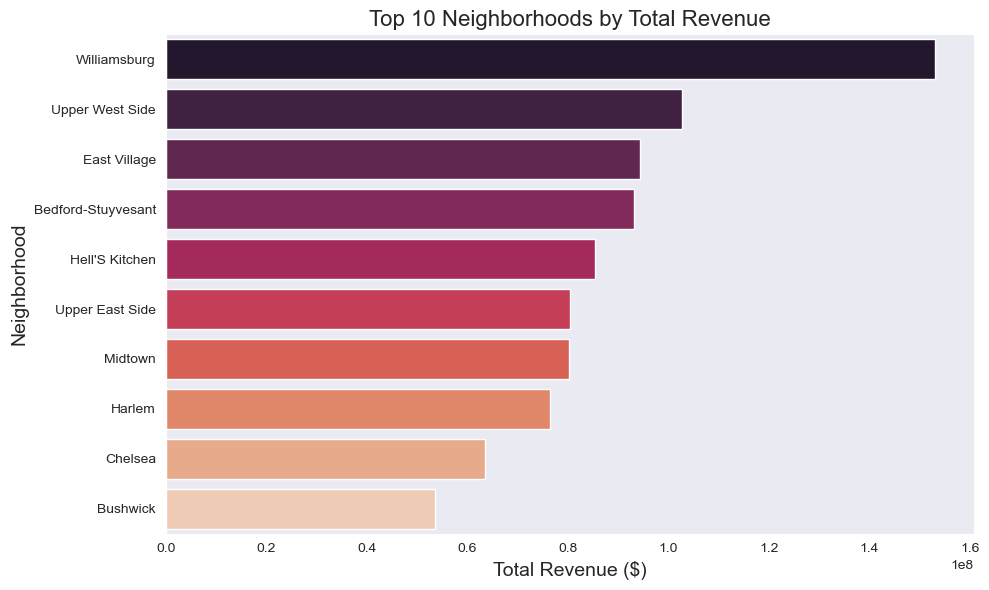

In [58]:
# Top 10 neighborhoods by revenue
top_neighborhoods = df.groupby("neighbourhood")["estimated_annual_revenue"].sum().sort_values(ascending=False).head(10).reset_index()
print(top_neighborhoods)

# Visualize top 10 neighborhoods by revenue
plt.figure(figsize=(10, 6))
sns.barplot(data=top_neighborhoods, y="neighbourhood", x="estimated_annual_revenue", palette="rocket", hue="neighbourhood", legend=False)
plt.xlabel("Total Revenue ($)", fontsize=14)
plt.ylabel("Neighborhood", fontsize=14)
plt.title("Top 10 Neighborhoods by Total Revenue", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/top_10_neighborhoods_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

In [59]:
# Correlation between price and estimated revenue
df[["price", "estimated_annual_revenue"]].corr()

,price,estimated_annual_revenue
price,1.000000,0.740579
estimated_annual_revenue,0.740579,1.000000


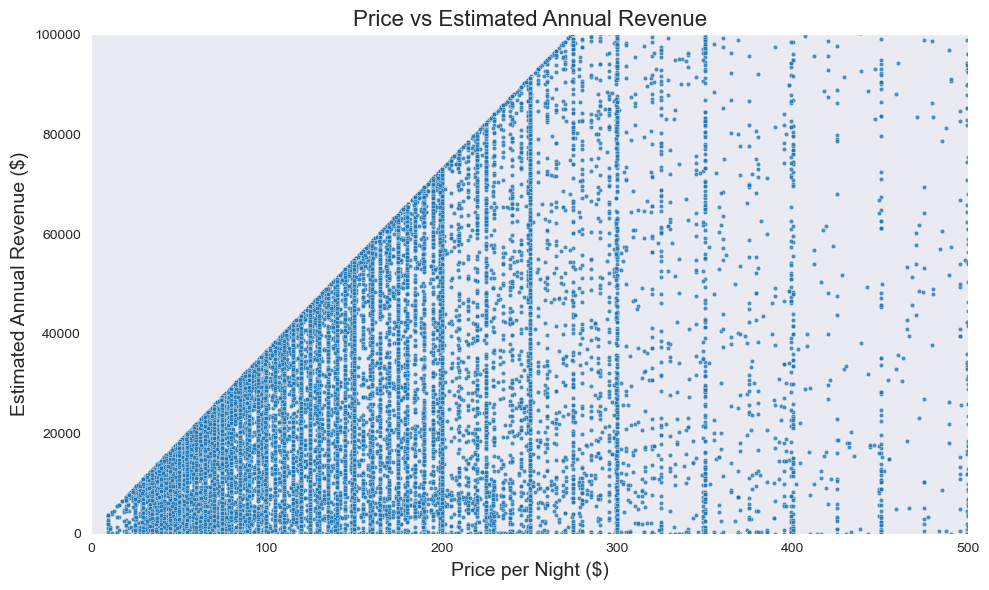

In [60]:
# Scatter plot: Price vs Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="price", y="estimated_annual_revenue", alpha=0.8, s=10)
plt.xlabel("Price per Night ($)", fontsize=14)
plt.ylabel("Estimated Annual Revenue ($)",  fontsize=14)
plt.title("Price vs Estimated Annual Revenue",  fontsize=16)
plt.xlim(0, 500)
plt.ylim(0, 100000)
plt.tight_layout()
plt.savefig("../outputs/price_vs_revenue_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
# Top 10 hosts by total revenue
top_hosts_revenue = df.groupby(["host_id", "host_name"])["estimated_annual_revenue"].sum().sort_values(ascending=False).head(10).reset_index()
top_hosts_revenue

,host_id,host_name,estimated_annual_revenue
0,156158778,Sally,10187176
1,107434423,Blueground,7649777
2,219517861,Sonder (NYC),5656459
3,205031545,Red Awning,5195611
4,5143901,Erin,3650000
5,20582832,Kathrine,3650000
6,1235070,Olson,3649635
7,72390391,Jelena,2820000
8,3906464,Amy,2819718
9,11598359,Jonathan,2372500


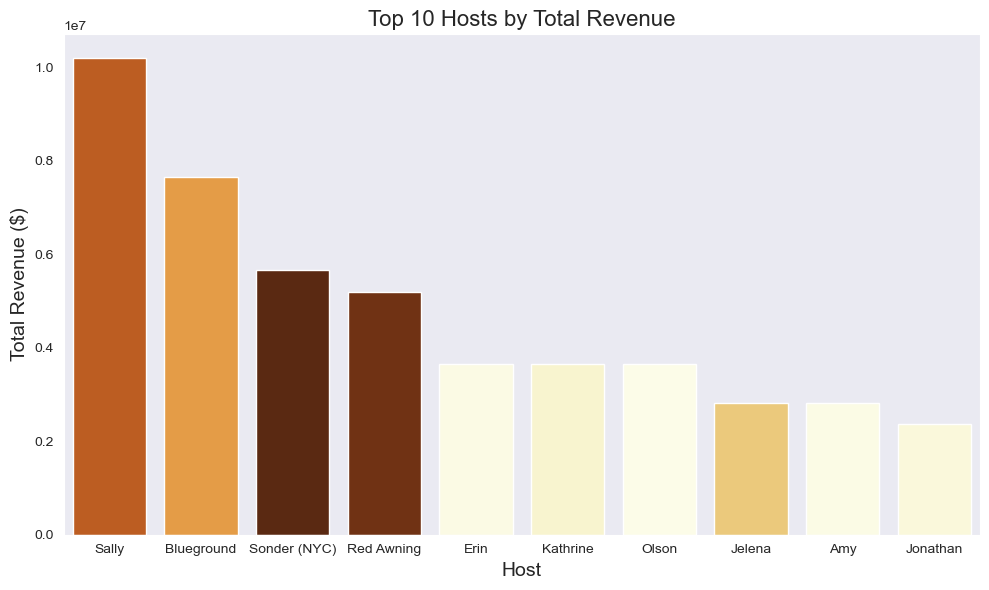

In [62]:
# Visualize top earning hosts by revenue
sns.set_style("dark")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_hosts_revenue, x="host_name", y="estimated_annual_revenue", palette="YlOrBr", hue="host_id", legend=False)
plt.ylabel("Total Revenue ($)", fontsize=14)
plt.xlabel("Host", fontsize=14)
plt.title("Top 10 Hosts by Total Revenue", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/top_10_hosts_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

In [63]:
# Correlation between availability and revenue
df[["availability_365", "estimated_annual_revenue"]].corr()

,availability_365,estimated_annual_revenue
availability_365,1.000000,-0.280691
estimated_annual_revenue,-0.280691,1.000000


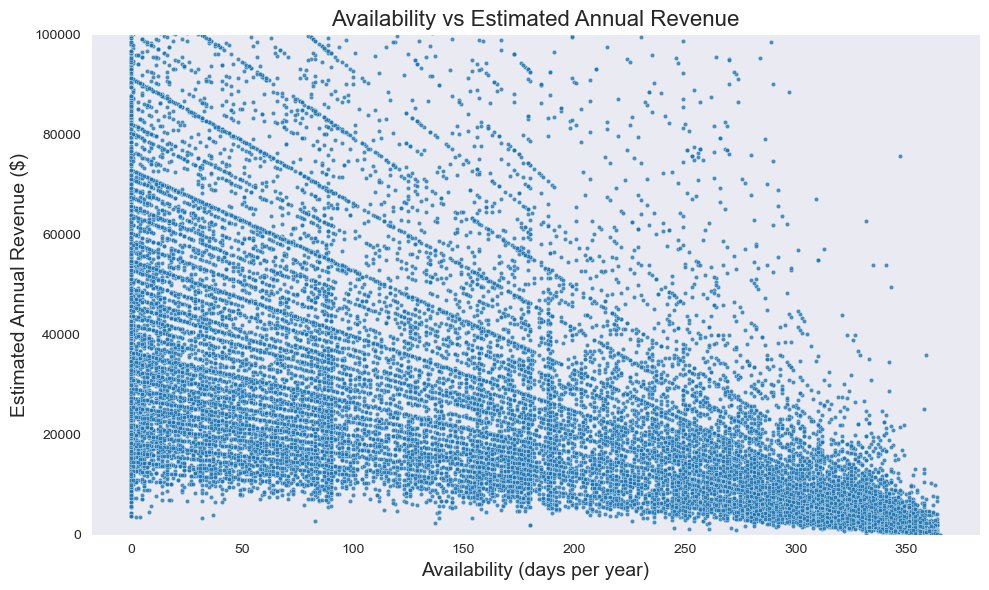

In [64]:
# Scatter plot: Availability vs Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="availability_365", y="estimated_annual_revenue", alpha=0.8, s=10)
plt.xlabel("Availability (days per year)", fontsize=14)
plt.ylabel("Estimated Annual Revenue ($)", fontsize=14)
plt.title("Availability vs Estimated Annual Revenue", fontsize=16)
plt.ylim(0, 100000)
plt.tight_layout()
plt.savefig("../outputs/availability_vs_estimated_annual_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- **Manhattan generates the highest total revenue** despite having similar listing counts to Brooklyn
- **Entire homes earn the most** per listing on average
- **Professional hosts don't necessarily earn more** per listing than casual hosts
- **Lower availability strongly correlates with higher revenue** (negative correlation)
- **Top neighborhoods** are concentrated in Manhattan and Brooklyn